In [ ]:
# Mounting Google Drive to access files in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading the dataset from Google Drive into a pandas DataFrame
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_Project/datasets/AVN_Corpus.csv')

In [ ]:
# Importing all required libraries for data processing, NLP, visualization, and feature extraction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
# Displaying dataset structure, column types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59436 entries, 0 to 59435
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   48209 non-null  object 
 1   receiver  46296 non-null  object 
 2   sender    47961 non-null  object 
 3   label     59436 non-null  float64
 4   body      59436 non-null  object 
 5   urls      59436 non-null  int64  
 6   date      47810 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.2+ MB


In [ ]:
# Displaying the first 5 rows of the dataset
df.head()

,subject,receiver,sender,label,body,urls,date
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,"Tue, 05 Aug 2008 16:31:02 -0700"
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,"Tue, 05 Aug 2008 18:31:03 -0500"
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,"Tue, 05 Aug 2008 20:28:00 -1200"
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,"Tue, 05 Aug 2008 17:31:20 -0600"
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,"Tue, 05 Aug 2008 19:31:21 -0400"


In [ ]:
df["label"] = df["label"].astype(int)

In [ ]:
# Displaying the number of rows and columns in the dataset
df.shape

(59436, 7)

In [ ]:
# Removing duplicate rows from the dataset in place
df.drop_duplicates(inplace=True)

In [ ]:
df = df.drop(columns=["sender", "receiver", "subject", "date"], errors='ignore')

In [ ]:
# Displaying the updated number of rows and columns after removing duplicates
df.shape

(53449, 3)

In [ ]:
df.head()

,label,body,urls
0,1,"Buck up, your troubles caused by small dimensi...",1
1,1,\nUpgrade your sex and pleasures with these te...,1
2,1,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1
3,0,Would anyone object to removing .so from this ...,1
4,1,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1


In [ ]:
# Checking for missing values in each column
df.isnull().sum()

,0
label,0
body,0
urls,0


In [ ]:
# Counting the frequency of each class label in the dataset
df['label'].value_counts()

,count
label,
1,27530
0,25919


In [ ]:
# Text preprocessing function: cleaning, tokenizing, removing stopwords, and lemmatizing text
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Replace URLs
    text = re.sub(r'http\S+', ' URL ', text)

    # Replace email addresses
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)

    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
# Applying text cleaning function to create 'clean_text' feature
df['clean_text'] = df['body'].apply(clean_text)

In [ ]:
# Displaying original and cleaned text for comparison
df[['body', 'clean_text']].head()

,body,clean_text
0,buck trouble caused small dimension soon becom...,buck trouble caused small dimension soon becom...
1,upgrade sex pleasure technique URL,upgrade sex pleasure technique url
2,daily top cnncom top video story aug pm edt to...,daily top cnncom top video story aug pm edt to...
3,would anyone object removing list tld basicall...,would anyone object removing list tld basicall...
4,welcomefastshippingcustomersupport URL,welcomefastshippingcustomersupport url


In [ ]:
df = df.drop_duplicates(subset=["clean_text"])

print(df.shape)

(43897, 4)


In [ ]:
df.head()

,label,body,urls,clean_text
0,1,"Buck up, your troubles caused by small dimensi...",1,buck trouble caused small dimension soon overb...
1,1,\nUpgrade your sex and pleasures with these te...,1,upgrade sex pleasure technique URL
2,1,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,daily top cnncom top video story aug pm edt to...
3,0,Would anyone object to removing .so from this ...,1,would anyone object removing list tld basicall...
4,1,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,welcomefastshippingcustomersupport URL


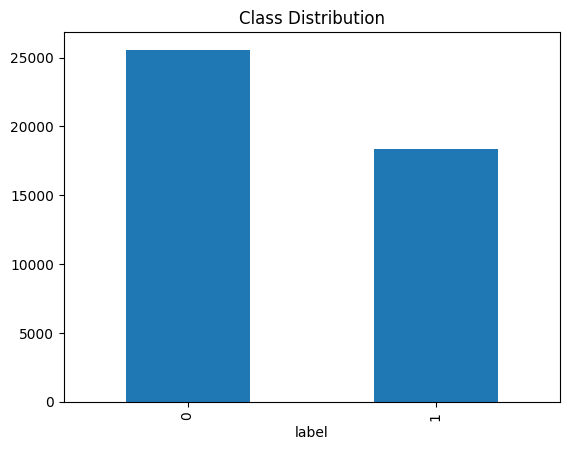

In [ ]:
# Visualizing class distribution using a bar chart
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [ ]:
# Saving the cleaned dataset to Google Drive as a CSV file
df.to_csv(
    '/content/drive/MyDrive/Phishing_Project/cleaned_data/cleaned_nlp_dataset.csv',
    index=False
)

In [ ]:
import re
def has_attachment(text):
    text = str(text).lower()

    pattern = r'\b(attach|attached|attachment|enclosed|pfa|see attached|find attached)\b|\b\w+\.(pdf|docx|xlsx|zip|jpg|png)\b'

    if re.search(pattern, text):
        return 1
    return 0

df["has_attachment"] = df["body"].apply(has_attachment)

In [ ]:
df["body"].apply(has_attachment).any()

np.True_

In [ ]:
df.groupby("label")["has_attachment"].sum()

,has_attachment
label,
0,1091
1,268


In [ ]:
df["has_attachment"].value_counts()

,count
has_attachment,
0,52090
1,1359


In [ ]:
pd.crosstab(df["has_attachment"], df["label"], normalize="index")

label,0,1
has_attachment,,
0,0.476637,0.523363
1,0.802796,0.197204


In [ ]:
df[df["body"].str.contains("attach", case=False, na=False)].head()

,label,body,urls,clean_text,has_attachment
18,0,carlos e r wrote begin pgp signed message hash...,1,carlos e r wrote begin pgp signed message hash...,1
19,0,steve jacob wrote forwarded message steve jaco...,1,steve jacob wrote forwarded message steve jaco...,1
27,0,benji weber wrote mike wrote notion malware li...,0,benji weber wrote mike wrote notion malware li...,1
60,0,sorry could attach k mail seems like big fit t...,0,sorry could attach k mail seems like big fit t...,1
101,0,send wekalist mailing list submission iuxxdkqk...,1,send wekalist mailing list submission iuxxdkqk...,1


In [ ]:
# Calculating the length of each email text
df['email_length'] = df['body'].apply(len)

In [ ]:
# Counting number of words in cleaned text
df['word_count'] = df['clean_text'].apply(
    lambda x: len(str(x).split())
)

In [ ]:
# Calculating average length of words in cleaned text
df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()])
    if len(str(x).split()) > 0 else 0
)

In [ ]:
# Counting uppercase letters in the text
df['capital_letter_count'] = df['body'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)

In [ ]:
# Counting exclamation marks in the text
df['exclamation_count'] = df['body'].apply(
    lambda x: str(x).count('!')
)

In [ ]:
# Counting sentences based on punctuation marks
df['sentence_count'] = df['body'].apply(
    lambda x: len(re.findall(r'[.!?]', str(x)))
)

In [ ]:
# Calculating ratio of unique words to total words
df['unique_word_ratio'] = df['clean_text'].apply(
    lambda x: len(set(str(x).split())) / (len(str(x).split()) + 1)
)

In [ ]:
# Calculating word density relative to email length
df['text_density'] = df['word_count'] / (df['email_length'] + 1)

In [ ]:
# Counting numeric digits in the text
df['digit_count'] = df['body'].apply(
    lambda x: sum(c.isdigit() for c in str(x))
)

In [ ]:
# Calculating ratio of uppercase letters to total email length
df['uppercase_ratio'] = df.apply(
    lambda row: row['capital_letter_count'] / (row['email_length'] + 1),
    axis=1
)

In [ ]:
# Counting patterns of repeated characters occurring 3 or more times consecutively
def repeated_chars(text):
    return len(re.findall(r'(.)\1{2,}', str(text)))

df['repeated_char_patterns'] = df['body'].apply(repeated_chars)

In [ ]:
# Counting URL-like patterns such as links and domain indicators
def url_like_patterns(text):
    return len(re.findall(r'(www|http|\.com|\.net|\.org)', str(text).lower()))

df['url_like_count'] = df['body'].apply(url_like_patterns)

In [ ]:
pip install pyspellchecker

In [ ]:
from spellchecker import SpellChecker

spell = SpellChecker()

def grammar_proxy(text):
    text = str(text).lower()[:150]
    words = text.split()

    if len(words) < 5:
        return 0

    misspelled = spell.unknown(words)
    return len(misspelled)


df['spelling_error_count'] = df['body'].fillna("").apply(grammar_proxy)

In [ ]:
# Installing language-tool-python library for grammar checking
!pip install language-tool-python

In [ ]:
import language_tool_python
import pandas as pd
from multiprocessing import Pool, cpu_count

tool = language_tool_python.LanguageTool('en-US')

# ---- FAST PRE-FILTER (skip easy texts) ----
def should_skip(text):
    if len(text) < 20:
        return True
    if text.isalpha():
        return True
    return False


# ---- CORE FUNCTION (faster) ----
def grammar_count(text):
    text = str(text)[:250]  # slightly smaller = faster

    if should_skip(text):
        return 0

    try:
        matches = tool.check(text)
        return len(matches)
    except:
        return 0


# ---- PARALLEL PROCESSING ----
def parallel_grammar(df, column='body'):
    texts = df[column].astype(str).tolist()

    with Pool(processes=cpu_count()) as pool:
        results = pool.map(grammar_count, texts)

    return results


df['grammar_error_count'] = parallel_grammar(df)

In [ ]:
# Calculating entropy of text based on character distribution
import math

def text_entropy(text):
    text = str(text)

    freq = Counter(text)

    probs = [f / len(text) for f in freq.values()]

    return -sum(p * math.log2(p) for p in probs)

df['text_entropy'] = df['body'].apply(text_entropy)

In [ ]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def action_density_batch(text_series):
    texts = text_series.fillna("").astype(str).str.lower().tolist()

    # tokenize ALL at once (faster than row loop)
    tokenized_texts = [word_tokenize(t) for t in texts]

    # flatten all tokens for batch POS tagging
    all_words = [w for doc in tokenized_texts for w in doc]

    # POS tag everything at once
    tagged_all = pos_tag(all_words)

    # rebuild per-document counts
    results = []
    idx = 0

    for doc in tokenized_texts:
        if len(doc) == 0:
            results.append(0)
            continue

        chunk = tagged_all[idx: idx + len(doc)]
        idx += len(doc)

        verb_count = sum(1 for _, tag in chunk if tag.startswith('VB'))
        results.append(verb_count / len(doc))

    return results


df['action_density'] = action_density_batch(df['body'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
corr = df[numerical_features + ["label"]].corr()

print(corr["label"].sort_values(ascending=False))

label                     1.000000
uppercase_ratio           0.145393
readability_score         0.101662
spelling_error_count      0.082937
avg_word_length           0.078160
grammar_error_count       0.016466
repeated_char_patterns   -0.003133
text_entropy             -0.008631
url_like_count           -0.028197
has_attachment           -0.082545
email_length             -0.098982
word_count               -0.127037
action_density           -0.240862
Name: label, dtype: float64


In [ ]:
# Displaying the first 5 rows of the dataset to verify engineered features
df.head()

,label,body,urls,clean_text,has_attachment,email_length,word_count,avg_word_length,capital_letter_count,exclamation_count,sentence_count,unique_word_ratio,text_density,uppercase_ratio,repeated_char_patterns,url_like_count,grammar_error_count,text_entropy,spelling_error_count,action_density
0,1,buck trouble caused small dimension soon becom...,1,buck trouble caused small dimension soon becom...,0,153,22,6.000000,3,0,0,0.956522,0.142857,0.019481,0,0,4,4.148747,3,0.227273
1,1,upgrade sex pleasure technique URL,1,upgrade sex pleasure technique url,0,34,5,6.000000,3,0,0,0.833333,0.142857,0.085714,0,0,1,4.020855,1,0.000000
2,1,daily top cnncom top video story aug pm edt to...,1,daily top cnncom top video story aug pm edt to...,0,1138,182,5.258242,72,0,0,0.677596,0.159789,0.063213,2,0,8,4.297694,6,0.153846
3,0,would anyone object removing list tld basicall...,1,would anyone object removing list tld basicall...,0,11068,1648,5.714199,1404,0,0,0.505761,0.148884,0.126841,194,187,7,4.345254,5,0.024242
4,1,welcomefastshippingcustomersupport URL,1,welcomefastshippingcustomersupport url,0,38,2,18.500000,3,0,0,0.666667,0.051282,0.076923,0,0,1,4.188331,0,0.000000


In [ ]:
# Saving the final processed dataset with all engineered features to Google Drive
df.to_csv(
    '/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_snehansha.csv',
    index=False
)

In [ ]:
# Loading the dataset from Google Drive into a pandas DataFrame
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_Project/final_dataset/final_preprocessed_dataset_snehansha.csv')

In [ ]:
print("Total Samples:", df.shape[0])

Total Samples: 44000


In [ ]:
print(df["label"].value_counts())

label
0    25555
1    18445
Name: count, dtype: int64


In [ ]:
print(df["label"].value_counts(normalize=True) * 100)

label
0    58.079545
1    41.920455
Name: proportion, dtype: float64


In [ ]:
df.head()

,label,body,urls,clean_text,has_attachment,email_length,word_count,avg_word_length,capital_letter_count,exclamation_count,sentence_count,unique_word_ratio,text_density,uppercase_ratio,repeated_char_patterns,url_like_count,grammar_error_count,text_entropy,spelling_error_count,action_density
0,1,buck trouble caused small dimension soon becom...,1,buck trouble caused small dimension soon becom...,0,153,22,6.000000,3,0,0,0.956522,0.142857,0.019481,0,0,4,4.148747,3,0.227273
1,1,upgrade sex pleasure technique URL,1,upgrade sex pleasure technique url,0,34,5,6.000000,3,0,0,0.833333,0.142857,0.085714,0,0,1,4.020855,1,0.000000
2,1,daily top cnncom top video story aug pm edt to...,1,daily top cnncom top video story aug pm edt to...,0,1138,182,5.258242,72,0,0,0.677596,0.159789,0.063213,2,0,8,4.297694,6,0.153846
3,0,would anyone object removing list tld basicall...,1,would anyone object removing list tld basicall...,0,11068,1648,5.714199,1404,0,0,0.505761,0.148884,0.126841,194,187,7,4.345254,5,0.024242
4,1,welcomefastshippingcustomersupport URL,1,welcomefastshippingcustomersupport url,0,38,2,18.500000,3,0,0,0.666667,0.051282,0.076923,0,0,1,4.188331,0,0.000000


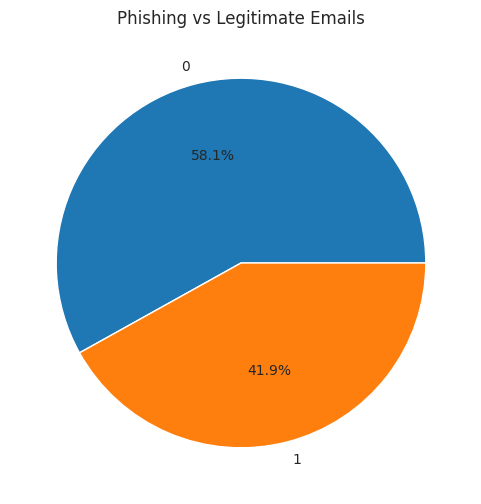

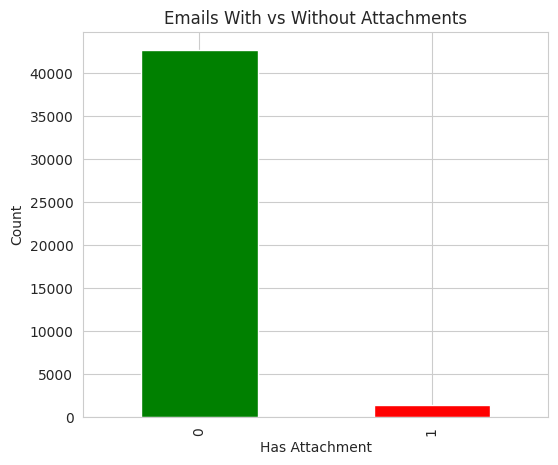

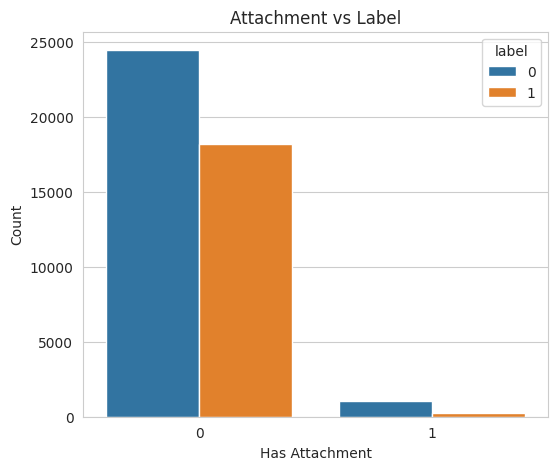

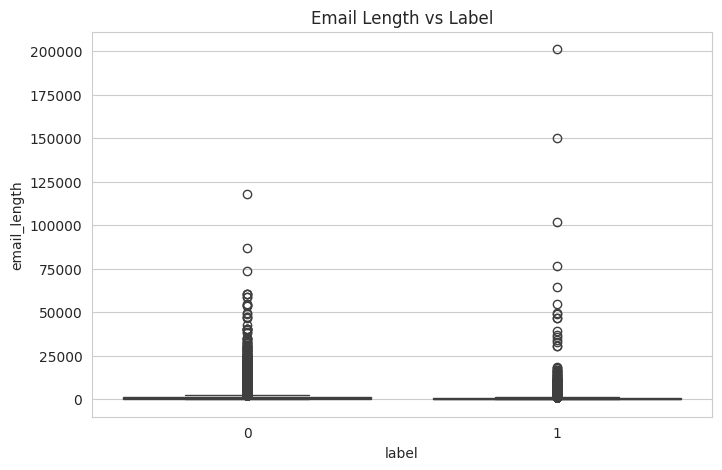

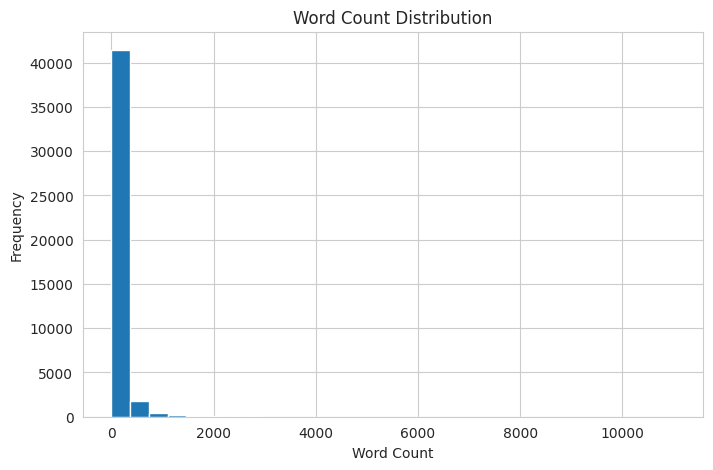

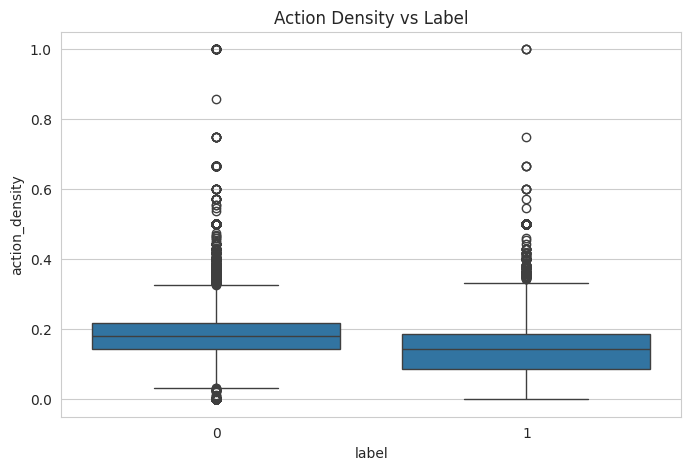

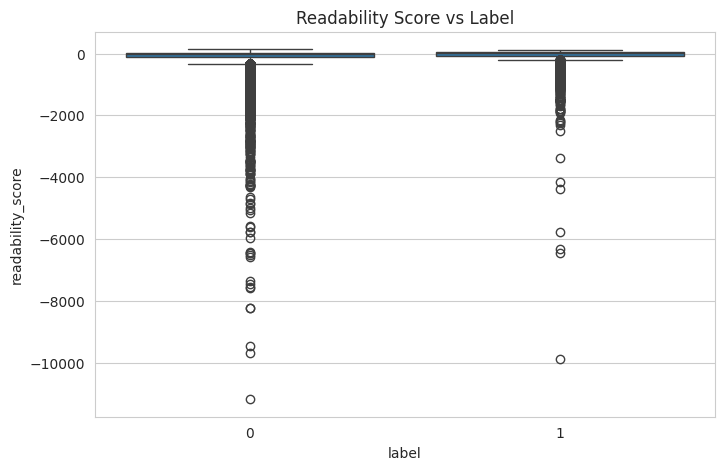

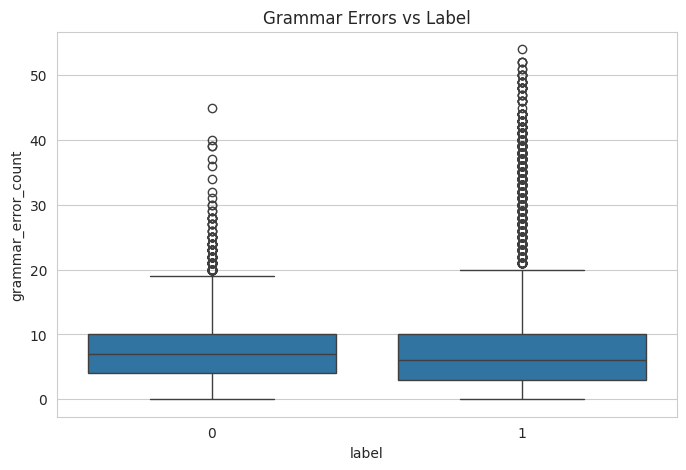

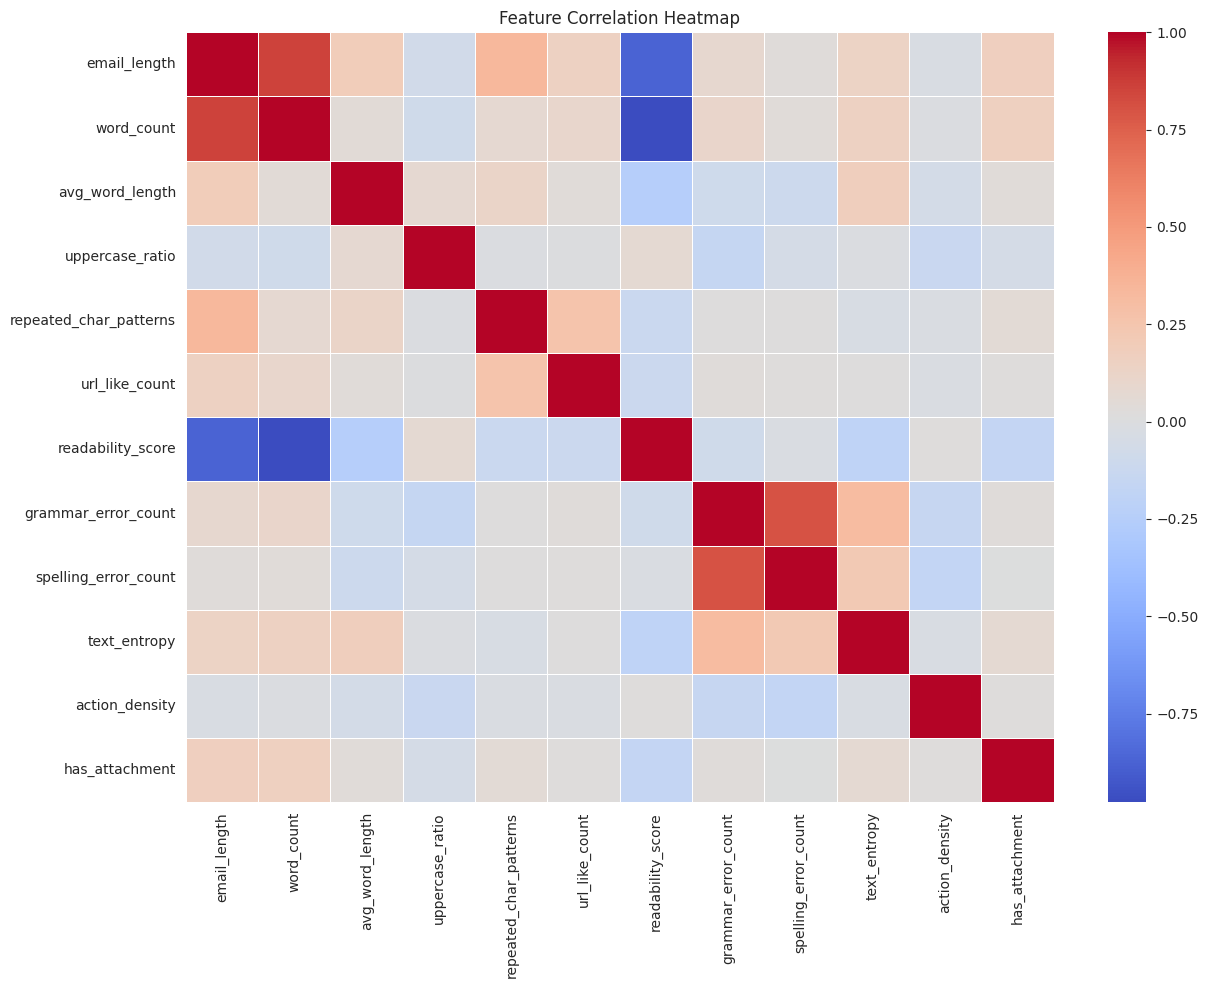

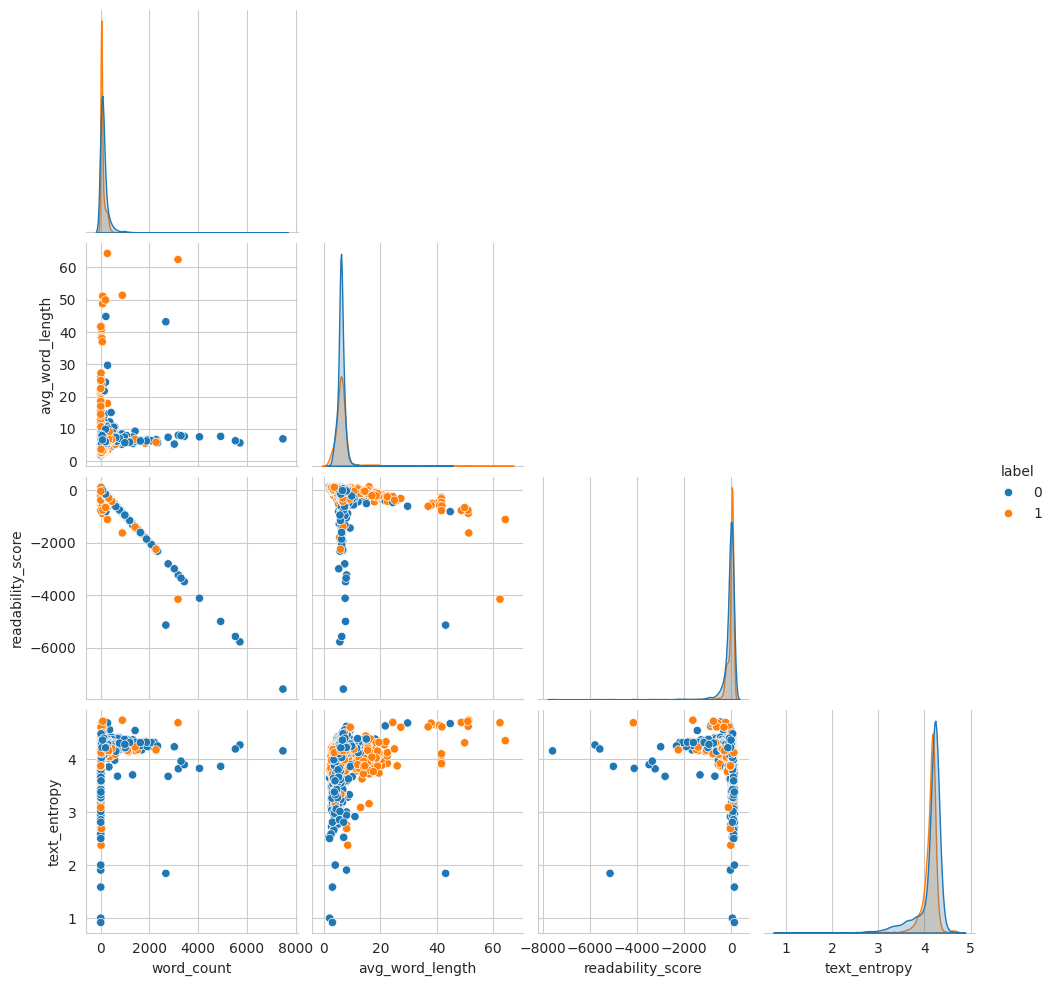

In [ ]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# =========================================================
# Label distribution pie chart
# =========================================================

plt.figure(figsize=(6,6))
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Phishing vs Legitimate Emails')
plt.ylabel('')
plt.show()


# =========================================================
# Has attachment distribution
# =========================================================

plt.figure(figsize=(6,5))
df['has_attachment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Emails With vs Without Attachments')
plt.xlabel('Has Attachment')
plt.ylabel('Count')
plt.show()


# =========================================================
# Attachment vs label relationship
# =========================================================

plt.figure(figsize=(6,5))
sns.countplot(x='has_attachment', hue='label', data=df)
plt.title('Attachment vs Label')
plt.xlabel('Has Attachment')
plt.ylabel('Count')
plt.show()


# =========================================================
# Email length vs label
# =========================================================

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='email_length', data=df)
plt.title('Email Length vs Label')
plt.show()


# =========================================================
# Word count distribution
# =========================================================

plt.figure(figsize=(8,5))
plt.hist(df['word_count'], bins=30)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


# =========================================================
# Action density vs label
# =========================================================

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='action_density', data=df)
plt.title('Action Density vs Label')
plt.show()

# =========================================================
# Grammar error vs label
# =========================================================

if 'grammar_error_count' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='label', y='grammar_error_count', data=df)
    plt.title('Grammar Errors vs Label')
    plt.show()


# =========================================================
# Correlation heatmap
# =========================================================

numerical_cols = [
    'email_length',
    'word_count',
    'avg_word_length',
    'uppercase_ratio',
    'repeated_char_patterns',
    'url_like_count',
    'grammar_error_count',
    'spelling_error_count',
    'text_entropy',
    'action_density',
    'has_attachment'
]

# Keep only existing columns
numerical_cols = [col for col in numerical_cols if col in df.columns]

plt.figure(figsize=(14,10))
corr = df[numerical_cols].corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


# =========================================================
# Pairplot (sampled for speed)
# =========================================================

important_features = [
    'word_count',
    'avg_word_length',
    'readability_score',
    'text_entropy',
    'label'
]

sample_df = df[important_features].sample(min(5000, len(df)), random_state=42)

sns.pairplot(sample_df, hue='label', corner=True)
plt.show()

In [ ]:
# =========================================================
# Numerical Features Selection
# =========================================================

# Selecting all meaningful engineered numeric features from dataset
numerical_features = [
    "uppercase_ratio",
    "url_like_count",
    "text_entropy",
    "action_density",
    "grammar_error_count",
    "has_attachment",
    "word_count",
    "avg_word_length",
    "repeated_char_patterns",
    "email_length",
    "spelling_error_count"
]

# =========================================================
# Input Features Preparation
# =========================================================

# Extract text feature for NLP model input
X_text = df["clean_text"]

# Extract numerical features for ML model input
X_num = df[numerical_features]

# Extract target label (spam or ham)
y = df["label"]

# =========================================================
# Train-Test Split
# =========================================================

from sklearn.model_selection import train_test_split

# Split dataset while maintaining class distribution
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler


X_train_text = X_train_text.fillna("")
X_test_text = X_test_text.fillna("")

# Scale numerical features
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [ ]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_tfidf, X_train_num_scaled])
X_test_final = hstack([X_test_tfidf, X_test_num_scaled])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression Model
lr = LogisticRegression(
    solver='saga',
    max_iter=10000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Train
lr.fit(X_train_final, y_train)

# Predict
pred_lr = lr.predict(X_test_final)

# Evaluation
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr))

Accuracy: 0.9663636363636363

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      5111
           1       0.95      0.97      0.96      3689

    accuracy                           0.97      8800
   macro avg       0.96      0.97      0.97      8800
weighted avg       0.97      0.97      0.97      8800



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train_final, y_train)

# Predict
pred_rf = rf.predict(X_test_final)

# Evaluation
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_rf))

Accuracy: 0.9761363636363637

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5111
           1       0.98      0.96      0.97      3689

    accuracy                           0.98      8800
   macro avg       0.98      0.97      0.98      8800
weighted avg       0.98      0.98      0.98      8800



In [ ]:
# MODEL VALIDATION & DATA LEAKAGE CHECKS

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# 1. CHECK CLASS DISTRIBUTION

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(df["label"].value_counts())

print("\nClass Percentage:\n")
print(df["label"].value_counts(normalize=True) * 100)


# 2. CHECK DUPLICATE ROWS

print("\n" + "=" * 60)
print("DUPLICATE DATA CHECK")
print("=" * 60)

duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)


# 3. CHECK DUPLICATE CLEAN TEXT

duplicate_text = df["clean_text"].duplicated().sum()

print("\nDuplicate clean_text rows:", duplicate_text)


# 4. TRAIN vs TEST ACCURACY

print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)

# Random Forest Train Accuracy
rf_train_pred = rf.predict(X_train_final)

rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Random Forest Test Accuracy
rf_test_acc = accuracy_score(y_test, pred_rf)

print("Random Forest Train Accuracy:", rf_train_acc)
print("Random Forest Test Accuracy :", rf_test_acc)

# Logistic Regression Train Accuracy
lr_train_pred = lr.predict(X_train_final)

lr_train_acc = accuracy_score(y_train, lr_train_pred)

# Logistic Regression Test Accuracy
lr_test_acc = accuracy_score(y_test, pred_lr)

print("\nLogistic Regression Train Accuracy:", lr_train_acc)
print("Logistic Regression Test Accuracy :", lr_test_acc)


# 5. CONFUSION MATRIX

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, pred_rf)

print("Random Forest Confusion Matrix:\n")
print(cm_rf)

print("\nRandom Forest Classification Report:\n")

print(classification_report(y_test, pred_rf))

# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, pred_lr)

print("\nLogistic Regression Confusion Matrix:\n")
print(cm_lr)

print("\nLogistic Regression Classification Report:\n")

print(classification_report(y_test, pred_lr))

# 6. FEATURE CORRELATION CHECK

print("\n" + "=" * 60)
print("HIGH FEATURE CORRELATION CHECK")
print("=" * 60)

correlation_matrix = X_num.corr()

high_corr = []

for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        if i != j:
            corr_value = correlation_matrix.loc[i, j]

            if abs(corr_value) > 0.95:
                high_corr.append((i, j, corr_value))

print("Highly Correlated Features:\n")

for item in high_corr:
    print(item)


# 7. CHECK FOR NULL VALUES

print("\n" + "=" * 60)
print("NULL VALUE CHECK")
print("=" * 60)

print(df.isnull().sum())


# 8. CROSS VALIDATION CONSISTENCY

print("\n" + "=" * 60)
print("CROSS VALIDATION CONSISTENCY")
print("=" * 60)

from sklearn.model_selection import cross_val_score

# Random Forest Cross Validation

rf_scores = cross_val_score(
    rf,
    X_train_final,
    y_train,
    cv=5,
    scoring='f1'
)

print("Random Forest F1 Scores:", rf_scores)
print("Random Forest Mean F1 :", rf_scores.mean())

# Logistic Regression Cross Validation

lr_scores = cross_val_score(
    lr,
    X_train_final,
    y_train,
    cv=5,
    scoring='f1'
)

print("\nLogistic Regression F1 Scores:", lr_scores)
print("Logistic Regression Mean F1 :", lr_scores.mean())


# 9. LABEL LEAKAGE CHECK

print("\n" + "=" * 60)
print("LABEL LEAKAGE CHECK")
print("=" * 60)

for column in numerical_features:

    phishing_mean = df[df["label"] == 1][column].mean()
    legit_mean = df[df["label"] == 0][column].mean()

    print(f"\nFeature: {column}")
    print("Phishing Mean:", phishing_mean)
    print("Legitimate Mean:", legit_mean)


# 10. FINAL OBSERVATION

print("\n" + "=" * 60)
print("VALIDATION CHECK COMPLETE")
print("=" * 60)

CLASS DISTRIBUTION
label
0    25555
1    18445
Name: count, dtype: int64

Class Percentage:

label
0    58.079545
1    41.920455
Name: proportion, dtype: float64

DUPLICATE DATA CHECK
Duplicate Rows: 0

Duplicate clean_text rows: 0

OVERFITTING CHECK
Random Forest Train Accuracy: 0.9999715909090909
Random Forest Test Accuracy : 0.9761363636363637

Logistic Regression Train Accuracy: 0.9689204545454545
Logistic Regression Test Accuracy : 0.9663636363636363

CONFUSION MATRIX
Random Forest Confusion Matrix:

[[5050   61]
 [ 149 3540]]

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5111
           1       0.98      0.96      0.97      3689

    accuracy                           0.98      8800
   macro avg       0.98      0.97      0.98      8800
weighted avg       0.98      0.98      0.98      8800


Logistic Regression Confusion Matrix:

[[4940  171]
 [ 125 3564]]

Logistic Regression Classifi

In [ ]:
import joblib

joblib.dump(
    tfidf,
    "/content/drive/MyDrive/Phishing_Project/nlp_features/tfidf_features.pkl"
)

['/content/drive/MyDrive/Phishing_Project/nlp_features/tfidf_features.pkl']

In [ ]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/Phishing_Project/nlp_features/scaler.pkl"
)

['/content/drive/MyDrive/Phishing_Project/nlp_features/scaler.pkl']

In [ ]:
joblib.dump(
    lr,
    "/content/drive/MyDrive/Phishing_Project/models/logistic_model.pkl"
)

joblib.dump(
    rf,
    "/content/drive/MyDrive/Phishing_Project/models/random_forest.pkl"
)

['/content/drive/MyDrive/Phishing_Project/models/random_forest.pkl']

In [ ]:
behavioral_features = [
    "email_length",
    "word_count",
    "uppercase_ratio",
    "capital_letter_count",
    "exclamation_count",
    "action_density",
    "url_like_count",
    "has_attachment",
    "repeated_char_patterns"
]

# Create dataframe from existing df
behavioral_df = df[behavioral_features]

# Save to CSV
behavioral_df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/nlp_features/behavioral_features.csv",
    index=False
)

In [ ]:
adversarial_features = [
    "uppercase_ratio",
    "repeated_char_patterns",
    "url_like_count",
    "grammar_error_count",
    "spelling_error_count",
    "text_entropy",
    "unique_word_ratio",
    "avg_word_length"
]

adversarial_df = df[adversarial_features]

adversarial_df.to_csv(
    "/content/drive/MyDrive/Phishing_Project/nlp_features/adversarial_features.csv",
    index=False
)

In [ ]:
!pip install transformers sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

bert_encoder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
texts = df["clean_text"].fillna("").tolist()

bert_embeddings = bert_encoder.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/1375 [00:00<?, ?it/s]

In [ ]:
print(bert_embeddings.shape)

(44000, 384)


In [ ]:
import numpy as np

np.save(
    "/content/drive/MyDrive/Phishing_Project/nlp_features/bert_embeddings.npy",
    bert_embeddings
)

In [ ]:
loaded = np.load(
    "/content/drive/MyDrive/Phishing_Project/nlp_features/bert_embeddings.npy"
)

print(loaded.shape)

(44000, 384)


In [ ]:
from sklearn.model_selection import train_test_split

X = bert_embeddings
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

bert_lr = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    random_state=42
)

bert_lr.fit(X_train, y_train)

pred = bert_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9455681818181818
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      5111
           1       0.93      0.94      0.94      3689

    accuracy                           0.95      8800
   macro avg       0.94      0.95      0.94      8800
weighted avg       0.95      0.95      0.95      8800



In [ ]:
from sklearn.ensemble import RandomForestClassifier

bert_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bert_rf.fit(X_train, y_train)

pred_rf = bert_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.9435227272727272
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5111
           1       0.98      0.88      0.93      3689

    accuracy                           0.94      8800
   macro avg       0.95      0.93      0.94      8800
weighted avg       0.95      0.94      0.94      8800



In [ ]:
# BERT + LOGISTIC REGRESSION VALIDATION

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score

print("\n" + "=" * 60)
print("BERT + LOGISTIC REGRESSION VALIDATION")
print("=" * 60)

# PREDICTIONS

bert_pred = bert_lr.predict(X_test)
bert_train_pred = bert_lr.predict(X_train)

# TRAIN & TEST ACCURACY

print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)

bert_train_acc = accuracy_score(y_train, bert_train_pred)
bert_test_acc = accuracy_score(y_test, bert_pred)

print("Train Accuracy :", bert_train_acc)
print("Test Accuracy  :", bert_test_acc)

gap = bert_train_acc - bert_test_acc

print("Accuracy Gap   :", round(gap, 4))

if gap > 0.05:
    print("Observation: Possible overfitting detected.")
else:
    print("Observation: No significant overfitting detected.")

# CONFUSION MATRIX

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm_bert = confusion_matrix(y_test, bert_pred)

print(cm_bert)

# CLASSIFICATION REPORT

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, bert_pred))

# CROSS VALIDATION

print("\n" + "=" * 60)
print("CROSS VALIDATION CONSISTENCY")
print("=" * 60)

cv_scores = cross_val_score(
    bert_lr,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

# PREDICTION DISTRIBUTION

print("\n" + "=" * 60)
print("PREDICTION DISTRIBUTION")
print("=" * 60)

import pandas as pd

print(pd.Series(bert_pred).value_counts())

# FINAL OBSERVATION

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

print(f"""
Train Accuracy : {bert_train_acc:.4f}
Test Accuracy  : {bert_test_acc:.4f}
Mean CV F1     : {cv_scores.mean():.4f}

The BERT embedding + Logistic Regression model shows
stable performance across training, testing and
cross-validation datasets.
""")


BERT + LOGISTIC REGRESSION VALIDATION

OVERFITTING CHECK
Train Accuracy : 0.9476704545454545
Test Accuracy  : 0.9455681818181818
Accuracy Gap   : 0.0021
Observation: No significant overfitting detected.

CONFUSION MATRIX
[[4839  272]
 [ 207 3482]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      5111
           1       0.93      0.94      0.94      3689

    accuracy                           0.95      8800
   macro avg       0.94      0.95      0.94      8800
weighted avg       0.95      0.95      0.95      8800


CROSS VALIDATION CONSISTENCY
F1 Scores: [0.93355537 0.93613445 0.93317741 0.9372793  0.93259742]
Mean F1 Score: 0.9345487926156169
Std Dev: 0.0018245766443341343

PREDICTION DISTRIBUTION
0    5046
1    3754
Name: count, dtype: int64

VALIDATION COMPLETE

Train Accuracy : 0.9477
Test Accuracy  : 0.9456
Mean CV F1     : 0.9345

The BERT embedding + Logistic Regression model shows
stable performance 

In [ ]:
import joblib

joblib.dump(
    bert_lr,
    "/content/drive/MyDrive/Phishing_Project/models/bert_model/bert_classifier.pkl"
)

['/content/drive/MyDrive/Phishing_Project/models/bert_model/bert_classifier.pkl']

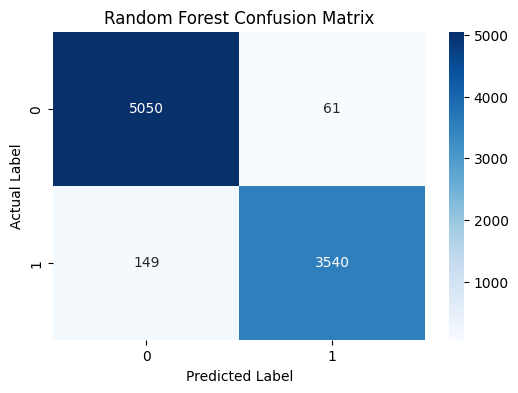

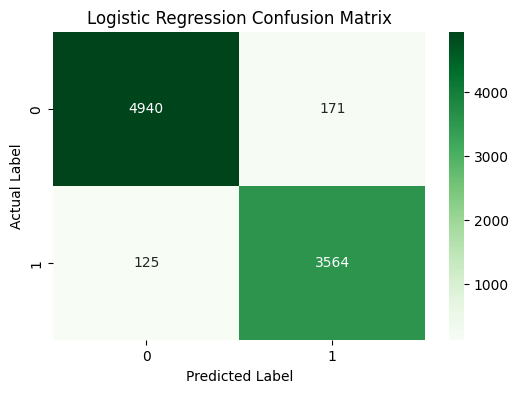

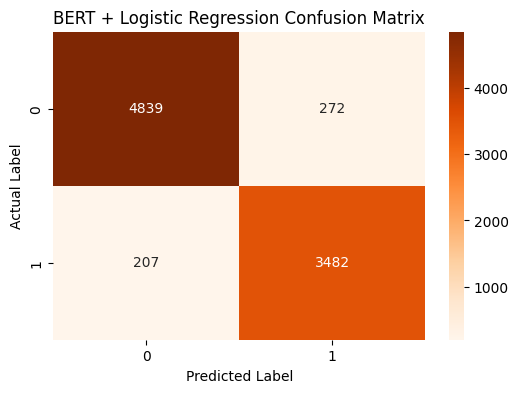


All Confusion Matrix images saved successfully.
Location: /content/drive/MyDrive/Phishing_Project/reports


In [ ]:
# =========================================================
# CONFUSION MATRIX VISUALIZATION & SAVE TO REPORTS
# =========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

reports_path = "/content/drive/MyDrive/Phishing_Project/reports"

# =========================================================
# CREATE CONFUSION MATRICES
# =========================================================

cm_rf = confusion_matrix(y_test, pred_rf)

cm_lr = confusion_matrix(y_test, pred_lr)

cm_bert = confusion_matrix(y_test, pred)

# =========================================================
# RANDOM FOREST CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.savefig(
    f"{reports_path}/random_forest_confusion_matrix.jpeg",
    format='jpeg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# =========================================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.savefig(
    f"{reports_path}/logistic_regression_confusion_matrix.jpeg",
    format='jpeg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# =========================================================
# BERT + LOGISTIC REGRESSION CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('BERT + Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.savefig(
    f"{reports_path}/bert_confusion_matrix.jpeg",
    format='jpeg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# =========================================================
# COMPLETION MESSAGE
# =========================================================

print("\nAll Confusion Matrix images saved successfully.")
print(f"Location: {reports_path}")

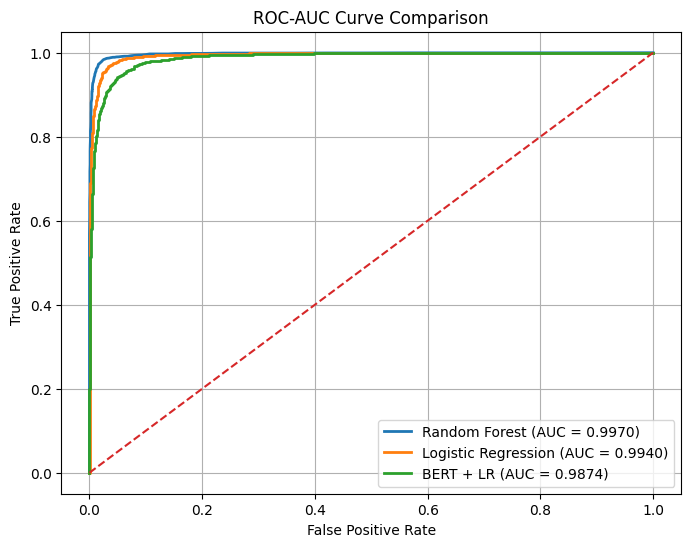

Random Forest AUC Score       : 0.9970
Logistic Regression AUC Score: 0.9940
BERT + LR AUC Score          : 0.9874

ROC-AUC image saved successfully.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

reports_path = "/content/drive/MyDrive/Phishing_Project/reports"

# =========================================================
# RANDOM FOREST ROC CURVE
# =========================================================

rf_probs = rf.predict_proba(X_test_final)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

# =========================================================
# LOGISTIC REGRESSION ROC CURVE
# =========================================================

lr_probs = lr.predict_proba(X_test_final)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

# =========================================================
# BERT + LOGISTIC REGRESSION ROC CURVE
# =========================================================

bert_probs = bert_lr.predict_proba(X_test)[:, 1]
bert_auc = roc_auc_score(y_test, bert_probs)

# =========================================================
# COMPUTE ROC COORDINATES
# =========================================================

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

bert_fpr, bert_tpr, _ = roc_curve(y_test, bert_probs)

# =========================================================
# PLOT ROC CURVES
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.4f})'
)

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {lr_auc:.4f})'
)

plt.plot(
    bert_fpr,
    bert_tpr,
    linewidth=2,
    label=f'BERT + LR (AUC = {bert_auc:.4f})'
)

# Random Classifier Baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

# =========================================================
# SAVE IMAGE
# =========================================================

plt.savefig(
    f"{reports_path}/roc_auc_comparison.jpeg",
    format="jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =========================================================
# PRINT SCORES
# =========================================================

print(f"Random Forest AUC Score       : {rf_auc:.4f}")
print(f"Logistic Regression AUC Score: {lr_auc:.4f}")
print(f"BERT + LR AUC Score          : {bert_auc:.4f}")

print("\nROC-AUC image saved successfully.")

In [ ]:
from scipy.sparse import hstack

# Full text column
X_text_full = df["clean_text"].fillna("")

# Full numerical features
X_num_full = df[numerical_features]

# Apply previously fitted scaler
X_num_full_scaled = scaler.transform(X_num_full)

# Apply previously fitted TF-IDF vectorizer
X_text_full_tfidf = tfidf.transform(X_text_full)

# Final feature matrix for entire dataset
X_full_final = hstack([
    X_text_full_tfidf,
    X_num_full_scaled
])

print(X_full_final.shape)

(44000, 5011)


In [ ]:
nlp_prob = rf.predict_proba(X_full_final)[:, 1]

nlp_pred = rf.predict(X_full_final)

In [ ]:
nlp_final = pd.DataFrame()

nlp_final["label"] = df["label"]

nlp_final["nlp_probability"] = nlp_prob

nlp_final["nlp_prediction"] = nlp_pred

nlp_final["email_length"] = df["email_length"]

nlp_final["word_count"] = df["word_count"]

nlp_final["avg_word_length"] = df["avg_word_length"]

nlp_final["uppercase_ratio"] = df["uppercase_ratio"]

nlp_final["url_like_count"] = df["url_like_count"]

nlp_final["text_entropy"] = df["text_entropy"]

nlp_final["action_density"] = df["action_density"]

nlp_final["grammar_error_count"] = df["grammar_error_count"]

nlp_final["spelling_error_count"] = df["spelling_error_count"]

nlp_final["has_attachment"] = df["has_attachment"]

nlp_final["repeated_char_patterns"] = df["repeated_char_patterns"]

print(nlp_final.head())

   label  nlp_probability  nlp_prediction  email_length  word_count  \
0      1             0.95               1           153          22   
1      1             0.99               1            34           5   
2      1             0.79               1          1138         182   
3      0             0.05               0         11068        1648   
4      1             1.00               1            38           2   

   avg_word_length  uppercase_ratio  url_like_count  text_entropy  \
0         6.000000         0.019481               0      4.148747   
1         6.000000         0.085714               0      4.020855   
2         5.258242         0.063213               0      4.297694   
3         5.714199         0.126841             187      4.345254   
4        18.500000         0.076923               0      4.188331   

   action_density  grammar_error_count  spelling_error_count  has_attachment  \
0        0.227273                    4                     3               0  

In [ ]:
nlp_final.to_csv(
    "/content/drive/MyDrive/Phishing_Project/final_dataset/nlp_final_features.csv",
    index=False
)

print("NLP Final Features Saved Successfully")

NLP Final Features Saved Successfully
